In [42]:
from langgraph.graph import StateGraph
from typing import List,Optional,TypedDict
from math import prod

### First Define A State (Shared Data)

In [43]:
# We Can Use Pydantic, DataClass, MessagesState -> langgraph.graph To Make Schema
class State(TypedDict):
    message : str

### Define The Node (Node = Function)

#### The Node Can Have Different Types

1 - Regular Node (update state)

2 - Tool Node (update or take action)

Any Node Can Update Or Make Action

In [44]:
def compliment(state : State) -> State:
    state['message'] = f"{state['message']} you're doing an amazing job learning LangGraph"
    return state

### Define The Graph Using "StateGraph"

In [45]:
graph = StateGraph(State)

graph.add_node("compliment", compliment)

graph.set_entry_point("compliment")
graph.set_finish_point("compliment")

app = graph.compile()

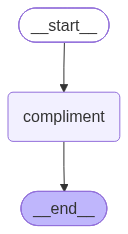

In [46]:
app

In [47]:
app.invoke({
    'message' : "Bishoy"
})

{'message': "Bishoy you're doing an amazing job learning LangGraph"}

### Multiple Inputs

In [48]:
class AgentState(TypedDict):
    name: str
    numbers: List[int]
    operation: str
    result: Optional[str]

In [49]:
def make_op(state : AgentState) -> AgentState:
    if state['operation'] == '+':
        state['result'] = f"Hi {state['name']}, your answer = {sum(state['numbers'])}"
        
    elif state['operation'] == '*':
        state['result'] = f"Hi {state['name']}, your answer = {prod(state['numbers'])}"
        
    else:
        state['result'] = f"Sorry {state['name']}, invalid operation"
        
    return state

In [50]:
graph = StateGraph(AgentState)

graph.add_node("make_op" , make_op)

graph.set_entry_point("make_op")
graph.set_finish_point("make_op")

app = graph.compile()

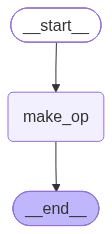

In [51]:
app

In [52]:
app.invoke({
    "name": "Bishoy",
    "numbers": [1,1,1,1,1],
    "operation": "+"
})

{'name': 'Bishoy',
 'numbers': [1, 1, 1, 1, 1],
 'operation': '+',
 'result': 'Hi Bishoy, your answer = 5'}